# 04 — Allocation Backtest

This notebook compares simple allocation policies in a walk-forward setting.

The objective is not to claim that the model produces alpha. The objective is to test whether regime-aware risk-budget control improves risk diagnostics relative to transparent constant-risk baselines.

Compared policies:

1. equal weight,
2. inverse volatility,
3. minimum variance,
4. regime-aware minimum variance with defensive risk-budget scaling.

Expected local outputs:

- `data/processed/backtest_strategy_returns.csv`
- `data/processed/backtest_performance_summary.csv`
- `data/processed/backtest_weights_long.csv`
- `reports/figures/04_cumulative_wealth.png`
- `reports/figures/04_drawdowns.png`
- `reports/figures/04_strategy_risk_summary.png`
- `reports/figures/04_regime_aware_weights.png`

In [ ]:
returns = pd.read_csv(DATA_DIR / "returns.csv", index_col=0, parse_dates=True)
regimes = pd.read_csv(DATA_DIR / "regime_labels.csv", index_col=0, parse_dates=True)["regime"]

aligned = returns.join(regimes.rename("regime"), how="inner").dropna()

returns_aligned = aligned[returns.columns]
regimes_aligned = aligned["regime"].astype(int)

print("Aligned returns:", returns_aligned.shape)
display(regimes_aligned.value_counts().sort_index().rename("n_obs"))

Aligned returns: (4788, 7)


regime
1      45
2    4743
Name: n_obs, dtype: int64

## 2. Backtest design

The walk-forward backtest follows conservative conventions:

- weights are estimated from past data only,
- weights are updated monthly,
- the lookback window is one trading year,
- transaction costs are deducted using one-way turnover,
- no leverage is introduced in this first version.

This is a research diagnostic, not a production simulation.

In [4]:
LOOKBACK = 252
REBALANCE_FREQUENCY = "ME"
TRANSACTION_COST_BPS = 2.0

risk_budgets = {
    0: 1.00,
    1: 0.70,
    2: 0.35,
}

print("Risk budgets by ordered regime:")
display(pd.Series(risk_budgets, name="risk_budget"))

Risk budgets by ordered regime:


0   1.0000
1   0.7000
2   0.3500
Name: risk_budget, dtype: float64

## 3. Define allocation policies through `src/regime_portfolio`

The allocation rules are deliberately simple and transparent.

The regime-aware policy does not change the optimizer itself. It changes the risk budget:

```text
low stress      -> mostly invested
medium stress   -> partially de-risked
high stress     -> strongly de-risked into SHY

In [5]:
strategies = {
    "equal_weight": lambda history, current_regime=None: equal_weight(history.columns),
    "inverse_volatility": make_regime_weight_function(
        method="inverse_volatility",
        defensive_asset="SHY",
    ),
    "minimum_variance": make_regime_weight_function(
        method="minimum_variance",
        defensive_asset="SHY",
    ),
    "regime_aware_min_var": make_regime_weight_function(
        method="minimum_variance",
        defensive_asset="SHY",
        budgets=risk_budgets,
    ),
}

list(strategies)

['equal_weight',
 'inverse_volatility',
 'minimum_variance',
 'regime_aware_min_var']

## 4. Run walk-forward backtests

Only the regime-aware strategy receives the regime state. The other baselines are intentionally regime-blind.

In [6]:
results = {}

for name, strategy_fn in strategies.items():
    use_regimes = regimes_aligned if name == "regime_aware_min_var" else None

    results[name] = run_backtest(
        returns=returns_aligned,
        strategy_fn=strategy_fn,
        regimes=use_regimes,
        lookback=LOOKBACK,
        rebalance_frequency=REBALANCE_FREQUENCY,
        transaction_cost_bps=TRANSACTION_COST_BPS,
    )

strategy_returns = pd.concat(
    {name: result.returns for name, result in results.items()},
    axis=1,
)

strategy_returns.columns = list(results.keys())

display(strategy_returns.tail())

,equal_weight,inverse_volatility,minimum_variance,regime_aware_min_var
Date,,,,
2026-06-04,0.0003,0.0006,0.0003,0.0006
2026-06-05,-0.0131,-0.0050,-0.0131,-0.0059
2026-06-08,0.0011,0.0003,0.0011,0.0007
2026-06-09,-0.0035,-0.0002,-0.0035,-0.0009
2026-06-10,-0.0082,-0.0021,-0.0082,-0.0029


## 5. Compare performance and risk diagnostics

The summary table includes return metrics, but the interpretation should emphasize risk control:

- maximum drawdown,
- CVaR,
- volatility,
- turnover,
- robustness across regimes.

A higher Sharpe ratio is useful only if it is accompanied by plausible risk behavior and not driven by overfitting.

In [7]:
performance_summary = compare_strategies(strategy_returns)

avg_turnover = pd.Series(
    {name: result.turnover.mean() for name, result in results.items()},
    name="avg_daily_turnover",
)

performance_summary = performance_summary.join(avg_turnover)

display(performance_summary)

,ann_return,ann_vol,sharpe_0rf,sortino_0rf,max_drawdown,calmar,cvar_5pct,skew,kurtosis,avg_daily_turnover
regime_aware_min_var,0.0296,0.0274,1.0778,1.7875,-0.0695,0.4253,0.0040,-0.1063,4.1915,0.0001
inverse_volatility,0.0297,0.0279,1.0651,1.7704,-0.0673,0.4408,0.0041,-0.0359,4.3659,0.0005
equal_weight,0.0439,0.0578,0.7597,1.2143,-0.1425,0.3079,0.0085,-0.3487,4.7293,0.0000
minimum_variance,0.0439,0.0578,0.7597,1.2143,-0.1425,0.3079,0.0085,-0.3487,4.7293,0.0000


## 6. Visual diagnostic — cumulative wealth

This plot compares cumulative wealth across strategies.

It should be read together with drawdown and CVaR diagnostics. A smoother path with lower drawdown may be more relevant to the project than the highest terminal wealth.

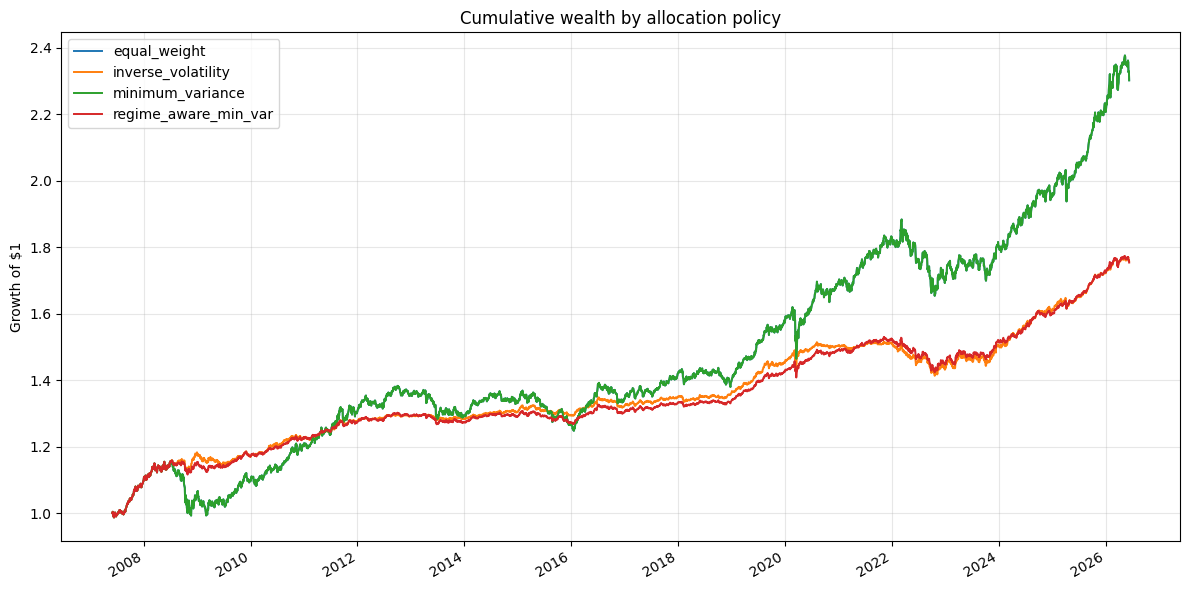

In [8]:
wealth = np.exp(strategy_returns.fillna(0.0).cumsum())

fig, ax = plt.subplots(figsize=(12, 6))

wealth.plot(ax=ax, linewidth=1.4)

ax.set_title("Cumulative wealth by allocation policy")
ax.set_ylabel("Growth of $1")
ax.set_xlabel("")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_cumulative_wealth.png", dpi=150)
plt.show()

## 7. Visual diagnostic — drawdowns

Drawdown is central to this project.

The regime-aware strategy should be evaluated primarily on whether it reduces severe drawdowns and tail losses without creating excessive turnover or unstable behavior.

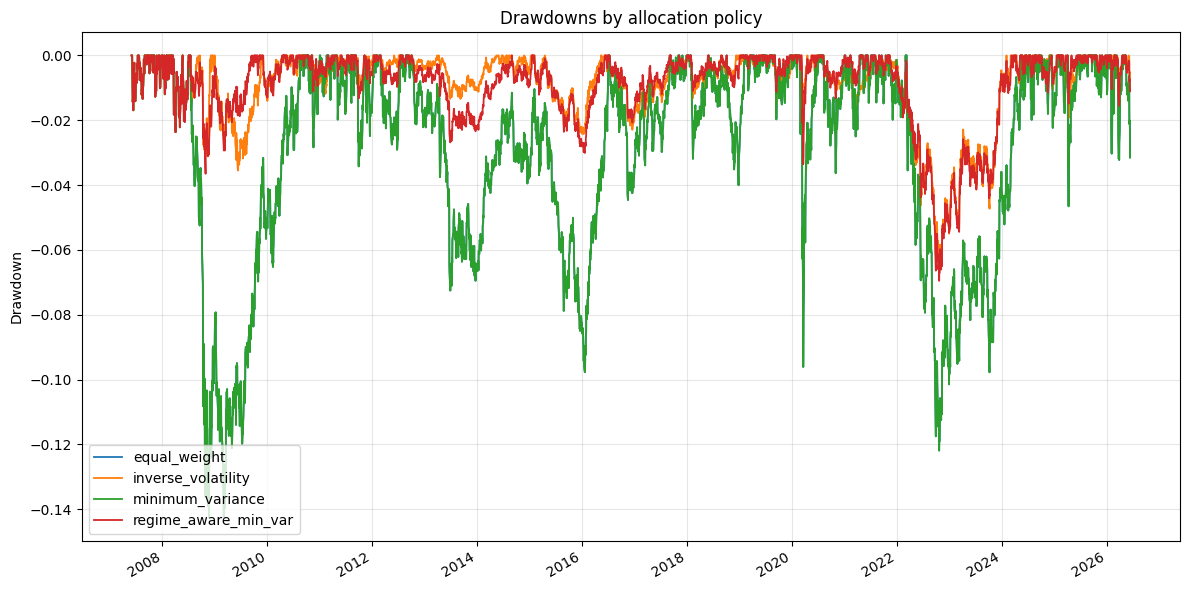

In [9]:
drawdowns = strategy_returns.apply(drawdown_series)

fig, ax = plt.subplots(figsize=(12, 6))

drawdowns.plot(ax=ax, linewidth=1.3)

ax.set_title("Drawdowns by allocation policy")
ax.set_ylabel("Drawdown")
ax.set_xlabel("")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower left")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_drawdowns.png", dpi=150)
plt.show()

## 8. Visual diagnostic — summary risk metrics

This bar plot focuses on metrics aligned with the project narrative:

- annualized volatility,
- maximum drawdown,
- CVaR,
- average turnover.

The objective is to compare risk behavior, not to select a strategy purely by return.

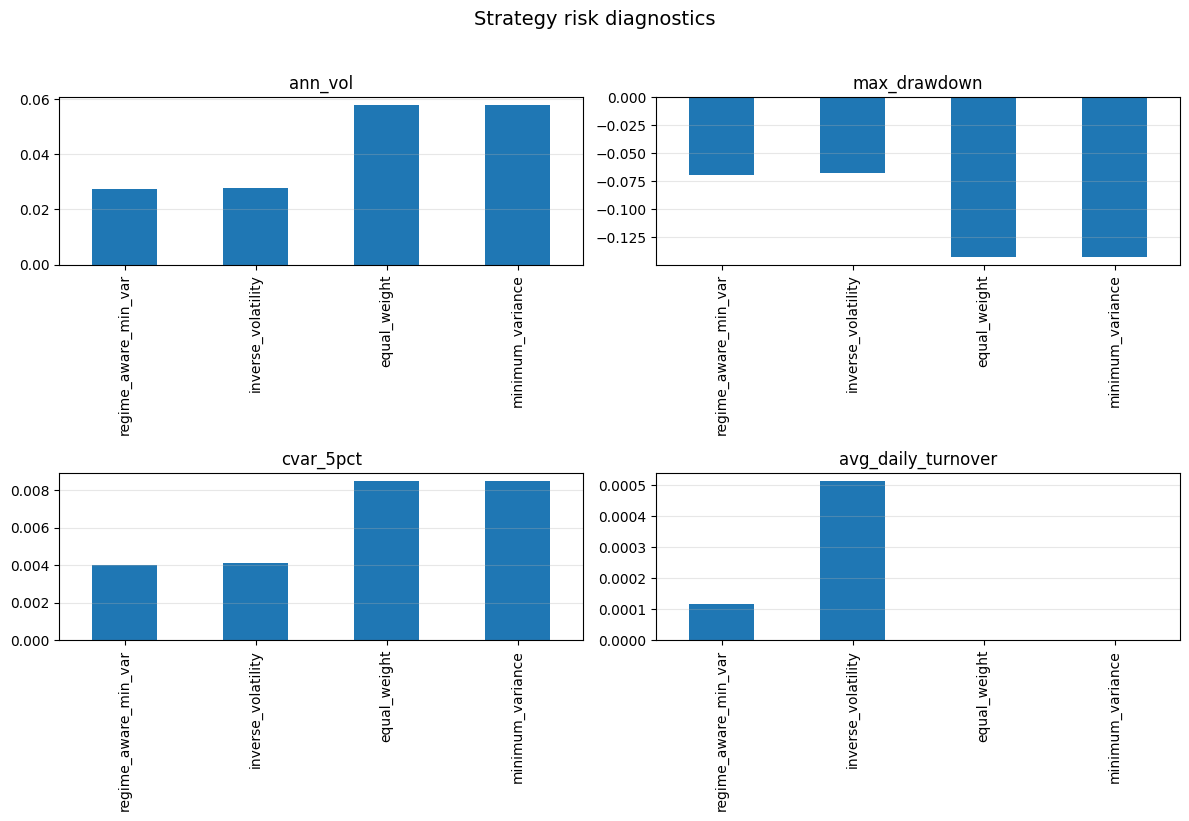

In [10]:
summary_metrics = performance_summary[
    ["ann_vol", "max_drawdown", "cvar_5pct", "avg_daily_turnover"]
].copy()

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
axes = axes.ravel()

for ax, metric in zip(axes, summary_metrics.columns):
    summary_metrics[metric].plot(kind="bar", ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("Strategy risk diagnostics", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_strategy_risk_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Visual diagnostic — regime-aware weights

This plot checks whether the regime-aware strategy behaves as designed.

In high-stress regimes, the defensive proxy `SHY` should absorb part of the risk budget.

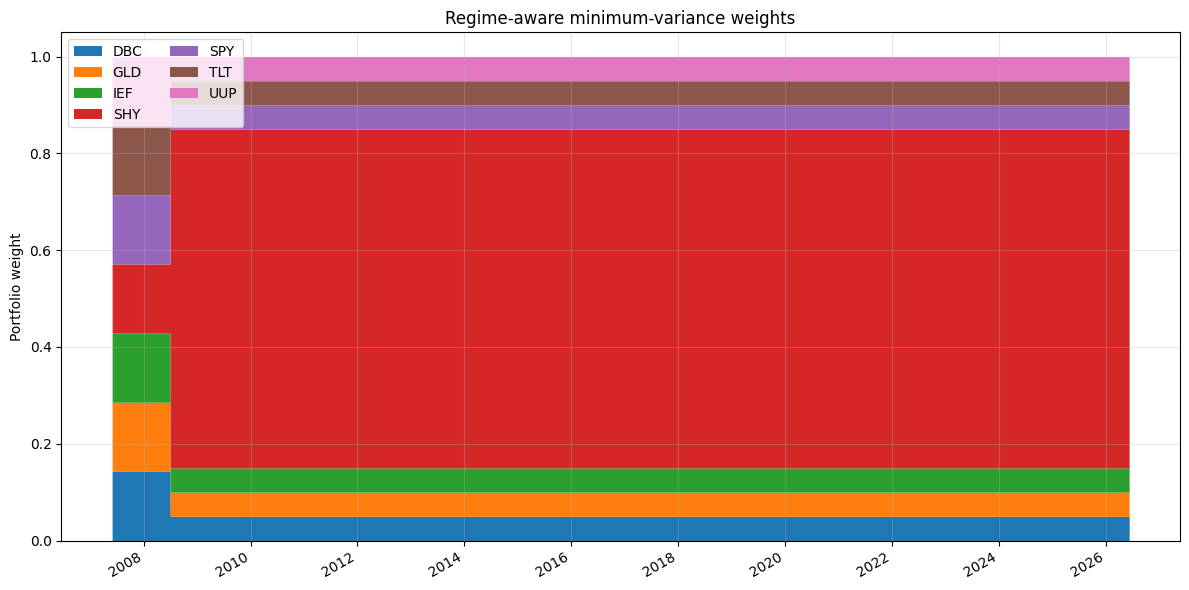

In [11]:
regime_aware_weights = results["regime_aware_min_var"].weights.copy()

fig, ax = plt.subplots(figsize=(12, 6))

regime_aware_weights.plot.area(ax=ax, linewidth=0.0)

ax.set_title("Regime-aware minimum-variance weights")
ax.set_ylabel("Portfolio weight")
ax.set_xlabel("")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", ncols=2)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_regime_aware_weights.png", dpi=150)
plt.show()

## 10. Export backtest outputs

The next notebook will reuse these outputs when comparing the SMDP-inspired stress-state policy.

In [12]:
strategy_returns.to_csv(DATA_DIR / "backtest_strategy_returns.csv")
performance_summary.to_csv(DATA_DIR / "backtest_performance_summary.csv")

weights_long = []

for name, result in results.items():
    tmp = result.weights.copy()
    tmp["date"] = tmp.index
    tmp = tmp.melt(
        id_vars="date",
        var_name="asset",
        value_name="weight",
    )
    tmp["strategy"] = name
    weights_long.append(tmp)

weights_long = pd.concat(weights_long, ignore_index=True)
weights_long.to_csv(DATA_DIR / "backtest_weights_long.csv", index=False)

print("Saved:")
print(DATA_DIR / "backtest_strategy_returns.csv")
print(DATA_DIR / "backtest_performance_summary.csv")
print(DATA_DIR / "backtest_weights_long.csv")

Saved:
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/backtest_strategy_returns.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/backtest_performance_summary.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/backtest_weights_long.csv


## 11. Notebook takeaway

This notebook compares transparent allocation baselines against a regime-aware risk-budget rule.

The appropriate claim is modest:

> regime-aware allocation is evaluated as a drawdown and tail-risk control mechanism, not as evidence of persistent return alpha.

The next notebook makes the degradation-control analogy explicit by constructing finite stress states and threshold-style intervention policies.